In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
file_path = '/content/drive/My Drive/TÜ Andmeteadus MSc/Machine Learning I/Project/cgm.txt'
df = pd.read_csv(file_path, sep="|")
df.head()

,PtID,Period,DataDtTm,CGM
0,1,1. Baseline,11DEC17:23:59:25,172
1,1,1. Baseline,12DEC17:00:04:24,170
2,1,1. Baseline,12DEC17:00:09:24,167
3,1,1. Baseline,12DEC17:00:14:25,163
4,1,1. Baseline,12DEC17:00:19:25,160


DCLP3 copy for the statistics part

In [6]:
dclp3 = df.copy()

In [7]:
df['DataDtTm'] = pd.to_datetime(df['DataDtTm'], format='%d%b%y:%H:%M:%S')

df = df.sort_values(['PtID', 'DataDtTm'])

df['delta_min'] = df.groupby('PtID')['DataDtTm'].diff().dt.total_seconds() / 60

df['delta_min'].describe()


,delta_min
count,9.032067e+06
mean,5.393085e+00
std,3.098620e+02
min,4.500000e+00
25%,5.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,9.275909e+05


In [8]:
df['CGM'].isna().sum()

df['CGM'].describe()

df['CGM_interp'] = df.groupby('PtID')['CGM'].transform(lambda x: x.interpolate(limit=3))

print(df['CGM'].isna().sum())
print(df['CGM'].describe())

df['CGM_mmol'] = df['CGM'] / 18

df['in_range'] = df['CGM_mmol'].between(4, 10)


0
count    9.032235e+06
mean     1.604207e+02
std      6.120771e+01
min      3.900000e+01
25%      1.160000e+02
50%      1.480000e+02
75%      1.930000e+02
max      4.010000e+02
Name: CGM, dtype: float64


In [9]:
df

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range
0,1,1. Baseline,2017-12-11 23:59:25,172,NaN,172,9.555556,True
1,1,1. Baseline,2017-12-12 00:04:24,170,4.983333,170,9.444444,True
2,1,1. Baseline,2017-12-12 00:09:24,167,5.000000,167,9.277778,True
3,1,1. Baseline,2017-12-12 00:14:25,163,5.016667,163,9.055556,True
4,1,1. Baseline,2017-12-12 00:19:25,160,5.000000,160,8.888889,True
...,...,...,...,...,...,...,...,...
4292120,171,2. Post Randomization,2018-10-24 08:50:04,174,5.000000,174,9.666667,True
4292121,171,2. Post Randomization,2018-10-24 08:55:04,192,5.000000,192,10.666667,False
4292122,171,2. Post Randomization,2018-10-24 09:00:04,189,5.000000,189,10.500000,False
4292123,171,2. Post Randomization,2018-10-24 09:05:04,183,5.000000,183,10.166667,False


# Clustering

* **EPISODE CLUSTER** = "What exactly was THAT particular meal like?"

Soovitatud klasterdajad:
- K-Means
- GMM
- HDBSCAN
- Spectral clustering

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

In [11]:
import numpy as np
import pandas as pd

def detect_episodes(df):
    df = df.sort_values("DataDtTm").copy()
    df = df.drop_duplicates(subset=['DataDtTm'], keep='last')

    df["gl"] = df["CGM"] / 18.0
    df["diff"] = df["gl"].diff().fillna(0)

    t = np.arange(len(df)) * 5

    y = df["gl"].values
    dy = df["diff"].values

    episodes = []
    last_start_idx = None

    minima = np.where((dy < 0) & (np.roll(dy, -1) > 0))[0]

    for start_idx in minima:

        if last_start_idx is not None and start_idx - last_start_idx < 18:
            continue

        baseline = y[start_idx]
        t_start = t[start_idx]

        mask_peak = (t - t_start >= 0) & (t - t_start <= 120)
        window_idx = np.where(mask_peak)[0]

        if len(window_idx) < 5:
            continue

        peak_idx = window_idx[np.argmax(y[mask_peak])]

        amplitude = y[peak_idx] - baseline
        peak_time = t[peak_idx] - t_start

        if amplitude < 1.5:
            continue
        if not (25 <= peak_time <= 80):
            continue
        if amplitude / peak_time < 0.015:
            continue

        mask_fall = (t >= t[peak_idx]) & (t <= t[peak_idx] + 120)
        fall_cand = np.where((dy < -0.05) & mask_fall)[0]

        if len(fall_cand) == 0:
            continue

        fall_idx = fall_cand[0]
        duration = t[fall_idx] - t_start

        if duration > 180:
            continue

        episodes.append({
            "PtID": df["PtID"].iloc[0],
            "start": df["DataDtTm"].iloc[start_idx],
            "start_idx": start_idx,
            "peak_time": float(peak_time),
            "amplitude": float(amplitude),
            "rise_slope": float(amplitude / peak_time),
            "duration": float(duration)
        })

        last_start_idx = start_idx

    return pd.DataFrame(episodes)


Make the curves of the episodes comparable (all with the same time step, length, start from 0)


In [12]:
def extract_curves_batch(df, episodes_df, window=120):
    """
    Teeb kõik episoodide kõverad võrreldavaks - sama pikkus, sama ajasamm, algavad 0-st!
    """

    if len(episodes_df) == 0:
        return np.array([]), []

    df = df.sort_values("DataDtTm").drop_duplicates(subset=['DataDtTm'], keep='last')
    df["gl"] = df["CGM"] / 18.0

    df = df.set_index("DataDtTm").sort_index()


    curves = []
    valid_indices = []


    for idx, row in episodes_df.iterrows():
        try:
            start_time = pd.to_datetime(row["start"])
            end_time = start_time + pd.Timedelta(minutes=window)

            seg = df.loc[start_time - pd.Timedelta(minutes=3):end_time + pd.Timedelta(minutes=3)]

            if len(seg) < 5:
                continue

            ti = pd.date_range(start=start_time, end=end_time, freq="5min")

            curve = seg["gl"].reindex(ti).interpolate(method='linear')

            if pd.isna(curve.iloc[0]):
                curve = curve.bfill()

            baseline = curve.iloc[0] if not pd.isna(curve.iloc[0]) else 0
            curve_normalized = (curve - baseline).values



            if len(curve_normalized) == 25 and not np.isnan(curve_normalized).any():
                curves.append(curve_normalized)
                valid_indices.append(idx)

        except Exception:
            continue

    return np.array(curves), valid_indices



Clustering episodes

Alustame optimeeritud töötlusega...
Ettevalmistus (duplikaatide eemaldamine)...

Töötlen 168 patsienti...


Patsiendid: 100%|██████████| 168/168 [03:00<00:00,  1.07s/it]



VALMIS! Aeg: 181.4s (3.02 min)
Kiirus: 0.9 patsienti/sek
Tuvastatud 71405 episoodi

Esimesed 5 episoodi:
   PtID               start  peak_time  amplitude  rise_slope  duration  \
0     1 2017-12-13 11:34:25       35.0   1.666667    0.047619      45.0   
1     1 2017-12-13 22:59:22       65.0   2.055556    0.031624      75.0   
2     1 2017-12-14 13:54:23       55.0   3.388889    0.061616      60.0   
3     1 2017-12-15 09:39:21       40.0   2.444444    0.061111      45.0   
4     1 2017-12-16 21:29:18       60.0   1.944444    0.032407      65.0   

   curve_idx  
0          0  
1          1  
2          2  
3          3  
4          4  

Klasterdamine...


NameError: name 'curves_pca' is not defined

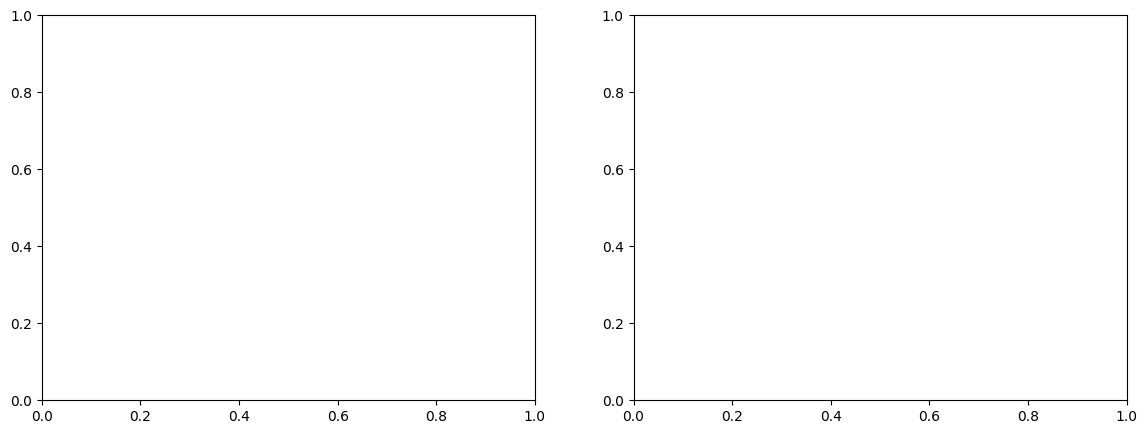

In [13]:
print("Alustame optimeeritud töötlusega...")
start_time = time.time()

episodes_list = []
curves_list = []
n_processed = 0
total_patients = df['PtID'].nunique()

print("Ettevalmistus (duplikaatide eemaldamine)...")
patient_groups = {}
for pid, group in df.groupby("PtID"):
    patient_groups[pid] = group

print(f"\nTöötlen {total_patients} patsienti...")

for pid, group in tqdm(patient_groups.items(), desc="Patsiendid"):
    ep = detect_episodes(group)

    if len(ep) == 0:
        n_processed += 1
        continue

    patient_curves, valid_indices = extract_curves_batch(group, ep)

    if len(patient_curves) > 0:
        valid_episodes = ep.loc[valid_indices].copy()
        valid_episodes = valid_episodes.drop(columns=['start_idx'], errors='ignore')

        episodes_list.append(valid_episodes)
        curves_list.append(patient_curves)

    n_processed += 1

#results
if len(episodes_list) > 0:
    episodes = pd.concat(episodes_list, ignore_index=True)
    curves = np.vstack(curves_list)
    episodes["curve_idx"] = np.arange(len(curves))
else:
    episodes = pd.DataFrame()
    curves = np.array([])

elapsed = time.time() - start_time
print(f"\n{'='*60}")
print(f"VALMIS! Aeg: {elapsed:.1f}s ({elapsed/60:.2f} min)")
print(f"Kiirus: {total_patients/elapsed:.1f} patsienti/sek")
print(f"Tuvastatud {len(episodes)} episoodi")
print(f"{'='*60}")

if len(episodes) > 0:
    print(f"\nEsimesed 5 episoodi:")
    print(episodes.head())

    # clustering
    print("\nKlasterdamine...")
    scaler = StandardScaler()
    curves_scaled = scaler.fit_transform(curves)

    n_clusters = 4  # predefined with the best result of 4 clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    episodes["cluster"] = kmeans.fit_predict(curves_scaled)

    # visualising
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # PCA scatter
    scatter = axes[0].scatter(curves_pca[:, 0], curves_pca[:, 1],
                             c=episodes["cluster"], cmap='viridis', alpha=0.6, s=30)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].set_title('Episoodid PCA ruumis')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0], label='Klaster')

    colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))
    for cluster_id in range(n_clusters):
        cluster_curves = curves[episodes["cluster"] == cluster_id]
        if len(cluster_curves) > 0:
            mean_curve = cluster_curves.mean(axis=0)
            std_curve = cluster_curves.std(axis=0)
            time_points = np.arange(25) * 5  # minutes

            axes[1].plot(time_points, mean_curve,
                        label=f'Klaster {cluster_id} (n={len(cluster_curves)})',
                        linewidth=2, color=colors[cluster_id])
            axes[1].fill_between(time_points,
                                mean_curve - std_curve,
                                mean_curve + std_curve,
                                alpha=0.2, color=colors[cluster_id])

    axes[1].set_xlabel('Aeg (minutid)')
    axes[1].set_ylabel('Glükoos muutus (mmol/L)')
    axes[1].set_title('Klastrite keskmised kõverad ± SD')
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # stats
    print(f"\n{'='*60}")
    print("KLASTRITE STATISTIKA")
    print(f"{'='*60}")
    for cluster_id in range(n_clusters):
        cluster_data = episodes[episodes["cluster"] == cluster_id]
        if len(cluster_data) > 0:
            print(f"\nKlaster {cluster_id} (n={len(cluster_data)}):")
            print(f"  Amplituud: {cluster_data['amplitude'].mean():.2f} ± {cluster_data['amplitude'].std():.2f} mmol/L")
            print(f"  Tippuaeg: {cluster_data['peak_time'].mean():.1f} ± {cluster_data['peak_time'].std():.1f} min")
            print(f"  Tõusukiirus: {cluster_data['rise_slope'].mean():.3f} ± {cluster_data['rise_slope'].std():.3f} mmol/L/min")
            print(f"  Kestus: {cluster_data['duration'].mean():.1f} ± {cluster_data['duration'].std():.1f} min")
            print(f"  Patsiendid: {cluster_data['PtID'].nunique()}")
else:
    print("\nÜhtegi episoodi ei tuvastatud!")


In [14]:
import numpy as np
import pandas as pd
from tqdm import tqdm

print("FAST VERSION – Adding 'time_above_baseline'...")

# 1) TIME ABOVE BASELINE – episode-curve based

def calculate_time_above_baseline_batch(df, episode_starts, window=120):
    df = df.sort_values("DataDtTm").drop_duplicates(subset=['DataDtTm'], keep='last')
    df["gl"] = df["CGM"] / 18.0
    df = df.set_index("DataDtTm").sort_index()

    results = []

    for start_time in episode_starts:
        try:
            start_time = pd.to_datetime(start_time)
            end_time = start_time + pd.Timedelta(minutes=window)

            seg = df.loc[start_time - pd.Timedelta(minutes=3):end_time + pd.Timedelta(minutes=3)]

            if len(seg) < 5:
                results.append(np.nan)
                continue

            ti = pd.date_range(start=start_time, end=end_time, freq="5min")
            curve = seg["gl"].reindex(ti).interpolate(method='linear')

            if pd.isna(curve.iloc[0]):
                curve = curve.bfill()

            baseline = curve.iloc[0] if not pd.isna(curve.iloc[0]) else 0
            curve_normalized = (curve - baseline).values

            if len(curve_normalized) != 25 or np.isnan(curve_normalized).any():
                results.append(np.nan)
                continue

            threshold = 1.0
            above_threshold = curve_normalized > threshold

            if above_threshold.any():
                last_high_idx = np.where(above_threshold)[0][-1]
                time_elevated = last_high_idx * 5
            else:
                time_elevated = 0

            results.append(time_elevated)

        except Exception:
            results.append(np.nan)

    return results


# 2) Add time_above_baseline and recovery_speed

if 'episodes' not in locals() and 'episodes' not in globals():
    print("'episodes' DataFrame not found!")
else:
    print(f"Found {len(episodes)} episodes")
    print("Processing per patient...")

    patient_groups = {pid: group for pid, group in df.groupby("PtID")}
    all_times = []

    for pid in tqdm(episodes['PtID'].unique(), desc="Patients"):
        patient_episodes = episodes[episodes['PtID'] == pid]

        times = calculate_time_above_baseline_batch(
            patient_groups[pid],
            patient_episodes['start'].values
        )

        all_times.extend(times)

    episodes['time_above_baseline'] = all_times

    n_before = len(episodes)
    episodes = episodes.dropna(subset=['time_above_baseline'])
    n_after = len(episodes)

    if n_before > n_after:
        print(f"Removed {n_before - n_after} episodes")

    episodes['recovery_speed'] = episodes['time_above_baseline'].apply(
        lambda x: 'Fast (<60min)' if x < 60 else 'Slow (≥60min)'
    )


    # 3) Episode clustering (keep your existing one)

    episode_cluster_labels = {
        0: "Moderate amplitude, long rise time, medium recovery",
        1: "Very high amplitude, very fast rise, very long recovery",
        2: "High amplitude, medium-speed rise, long recovery",
        3: "Low amplitude, fast peak, short duration, fast recovery"
    }

    if "cluster" in episodes.columns:
        episodes["episode_cluster_name"] = episodes["cluster"].map(episode_cluster_labels)
        print("Episode cluster names added.")
    else:
        print("'cluster' column not found – episode cluster names not added.")


    # 4) Episode-based PREDICT function (UPDATED)

    def predict_episode_summary(pid, start_date=None, end_date=None):
        eps = episodes[episodes["PtID"] == pid].copy()

        if start_date is not None:
            eps = eps[eps["start"] >= pd.to_datetime(start_date)]
        if end_date is not None:
            eps = eps[eps["start"] <= pd.to_datetime(end_date)]

        if len(eps) == 0:
            return {
                "PtID": pid,
                "episode_count": 0,
                "warning": "No episodes found in selected period!",
                "start_date": start_date,
                "end_date": end_date
            }

        episode_dist = (
            eps["episode_cluster_name"].value_counts().to_dict()
            if "episode_cluster_name" in eps.columns
            else {}
        )

        return {
            "PtID": pid,
            "episode_count": len(eps),
            "mean_amplitude": eps['amplitude'].mean(),
            "mean_peak_time": eps['peak_time'].mean(),
            "mean_rise_slope": eps['rise_slope'].mean(),
            "mean_duration": eps['duration'].mean(),
            "episode_cluster_distribution": episode_dist,
            "start_date": start_date,
            "end_date": end_date
        }


    # 5) Timing statistics

    def compute_patient_timing_stats(pid, start_date=None, end_date=None):
        eps = episodes[episodes["PtID"] == pid].copy()

        if start_date is not None:
            eps = eps[eps["start"] >= pd.to_datetime(start_date)]
        if end_date is not None:
            eps = eps[eps["start"] <= pd.to_datetime(end_date)]

        if len(eps) == 0:
            return None

        eps['start_dt'] = pd.to_datetime(eps['start'])
        eps['date'] = eps['start_dt'].dt.date
        eps['rounded_hour'] = eps['start_dt'].dt.hour + (eps['start_dt'].dt.minute >= 30).astype(int)
        eps['rounded_hour'] = eps['rounded_hour'] % 24   # 23:30 → 24 → 0
        eps['hour'] = eps['start_dt'].dt.hour

        episodes_per_day = eps.groupby("date").size().mean()
        top_hours = eps['rounded_hour'].value_counts().head(3)

        mean_high = eps['time_above_baseline'].mean()
        median_high = eps['time_above_baseline'].median()
        pct_2h = 100 * (eps['time_above_baseline'] >= 120).mean()

        slow = (eps['recovery_speed'] == 'Slow (≥60min)').sum()
        fast = (eps['recovery_speed'] == 'Fast (<60min)').sum()
        total = len(eps)

        return {
            "episodes_per_day": episodes_per_day,
            "top_hours": top_hours,
            "mean_high": mean_high,
            "median_high": median_high,
            "pct_2h": pct_2h,
            "slow": slow,
            "fast": fast,
            "total": total
        }


    # 6) Report output

    def print_patient_report(result):
        pid = result["PtID"]

        stats = compute_patient_timing_stats(
            pid,
            result["start_date"],
            result["end_date"]
        )

        print("\n🧬 EPISODE-BASED REPORT")
        print("=" * 40)

        print(f"👤 Patient: {pid}")

        if result["start_date"] or result["end_date"]:
            print("\n📅 Period:")
            print(f"  From: {result['start_date']}")
            print(f"  To:   {result['end_date']}")

        print(f"\n📦 Number of episodes: {result['episode_count']}")
        if result["episode_count"] == 0:
            print("No episodes found.")
            return

        print("\n📈 Mean episode values:")
        print(f"  • Amplitude: {result['mean_amplitude']:.2f} mmol/L")
        print(f"  • Peak time: {result['mean_peak_time']:.1f} min")
        print(f"  • Rise rate: {result['mean_rise_slope']:.3f} mmol/L/min")
        print(f"  • Duration: {result['mean_duration']:.1f} min")

        print("\n🍽️ Episode distribution across clusters:")
        for name, count in result['episode_cluster_distribution'].items():
            pct = 100 * count / result['episode_count']
            print(f"  • {name}: {count} episodes ({pct:.1f}%)")

        print("=" * 40)

        if stats is not None:
            print("\n⏰ TIMING ANALYSIS:")
            print(f"  • Episodes per day: {stats['episodes_per_day']:.2f}")
            print(f"  • Most frequent hours (episode start times):")
            for hour, count in stats["top_hours"].items():
                print(f"     - {hour:02d}:00 → {count} episodes")

            print("\n📊 GLUCOSE STAYING ELEVATED:")
            print(f"  • Mean: {stats['mean_high']:.1f} min")
            print(f"  • Median: {stats['median_high']:.1f} min")
            print(f"  • ≥2h episodes: {stats['pct_2h']:.1f}%")

            print("\n⚡ Recovery speed:")
            print(f"     - Slow (≥60min): {stats['slow']} episodes")
            print(f"     - Fast (<60min): {stats['fast']} episodes")

            print("=" * 40)


    print("\nYou can now use:")
    print("   r = predict_episode_summary(PATIENT_ID, start_date, end_date)")
    print("   print_patient_report(r)")



FAST VERSION – Adding 'time_above_baseline'...
Found 71405 episodes
Processing per patient...


Patients: 100%|██████████| 168/168 [01:35<00:00,  1.75it/s]

Episode cluster names added.

You can now use:
   r = predict_episode_summary(PATIENT_ID, start_date, end_date)
   print_patient_report(r)


Statisika osa prep

In [15]:
# Classify by the CGM_mmol is it in range, hypoglycemia, or hyperglycemia
def classify_glucose(val): # in mmol/L
    if val < 4.0:
        return 'hypoglycemia'
    elif val <= 10:
        return 'in_range'
    else:
        return 'hyperglycemia'

In [16]:
def assign_period(hour):
    if 0 <= hour < 3:
        return '00:00–03:00'
    elif 3 <= hour < 9:
        return '03:00–09:00'
    elif 9 <= hour < 12:
        return '09:00–12:00'
    elif 12 <= hour < 17:
        return '12:00–17:00'
    elif 17 <= hour < 21:
        return '17:00–21:00'
    else:
        return '21:00–00:00'

In [17]:
dclp3['DataDtTm'] = pd.to_datetime(dclp3['DataDtTm'], format='%d%b%y:%H:%M:%S')
# Extract date from 'DataDtTm' and sort
dclp3['date'] = dclp3['DataDtTm'].dt.date
dclp3 = dclp3.sort_values(['PtID', 'DataDtTm'])

# Extract time from 'DataDtTm' and sort
dclp3['time'] = dclp3['DataDtTm'].dt.time
dclp3['hour'] = dclp3['DataDtTm'].dt.hour
dclp3 = dclp3.sort_values(['PtID', 'DataDtTm'])

# Calculate the time difference between two events
dclp3['delta_min'] = dclp3.groupby('PtID')['DataDtTm'].diff().dt.total_seconds() / 60
dclp3['time_period'] = dclp3['hour'].apply(assign_period)
# Count missing values at 'CGM'
print("Missing values at column 'CGM': ", dclp3['CGM'].isna().sum())

print("\nSummary of column 'CGM'")
print(dclp3['CGM'].describe())

dclp3['CGM_mmol'] = dclp3['CGM'] / 18

# Create a column to check if the value of CGM is between 4–10 mmol/L
dclp3['in_range'] = dclp3['CGM_mmol'].between(4, 10)
dclp3['CGM_category'] = dclp3['CGM_mmol'].apply(classify_glucose)

Missing values at column 'CGM':  0

Summary of column 'CGM'
count    9.032235e+06
mean     1.604207e+02
std      6.120771e+01
min      3.900000e+01
25%      1.160000e+02
50%      1.480000e+02
75%      1.930000e+02
max      4.010000e+02
Name: CGM, dtype: float64


In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

def plot_patient_overview(pt, start_date, end_date, dclp3):

    # Fix date types
    dclp3['date'] = pd.to_datetime(dclp3['date'])
    dclp3['DataDtTm'] = pd.to_datetime(dclp3['DataDtTm'])

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    # Filter patient data
    subset = dclp3[
        (dclp3['PtID'] == pt) &
        (dclp3['date'] >= start_date) &
        (dclp3['date'] <= end_date)
    ].copy()

    if subset.empty:
        print(f"Patient {pt} has NO data between {start_date:%d.%m.%Y} -- {end_date:%d.%m.%Y}.")
        return

    # Prepare fields
    subset['hour'] = subset['DataDtTm'].dt.hour

    subset['zone'] = np.select(
        [subset['CGM_mmol'] < 4,
         subset['CGM_mmol'].between(4, 10),
         subset['CGM_mmol'] > 10],
        ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
        default='missing'
    )

    TIR = (subset['CGM_mmol'].between(4,10)).mean() * 100
    TBR = (subset['CGM_mmol'] < 4).mean() * 100
    TAR = (subset['CGM_mmol'] > 10).mean() * 100

    # Prepare hourly proportions
    hourly_summary = (
        subset.groupby('hour')['zone']
        .value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    )

    for h in range(24):
        if h not in hourly_summary.index:
            hourly_summary.loc[h] = [0,0,0]
    hourly_summary = hourly_summary.sort_index()

    sd = start_date.strftime("%d.%m.%Y")
    ed = end_date.strftime("%d.%m.%Y")
    date_text = sd if sd == ed else f"{sd} - {ed}"

    fig = plt.figure(figsize=(14,10))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

    ax1 = fig.add_subplot(gs[0, :])
    fig.suptitle(f'Patient no. {pt}\n{date_text}\nMain: Glucose level over time',
                 fontsize=14, fontweight='bold', y=0.95)

    # Main glycose curve
    ax1.axhspan(4, 10, color='forestgreen', alpha=0.15)
    ax1.plot(subset['DataDtTm'], subset['CGM_mmol'], color='mediumblue')

    # highlight highs and lows
    ax1.scatter(
        subset['DataDtTm'][subset['CGM_mmol'] > 10],
        subset['CGM_mmol'][subset['CGM_mmol'] > 10],
        color='orange', s=20, label='>10 mmol/L'
    )
    ax1.scatter(
        subset['DataDtTm'][subset['CGM_mmol'] < 4],
        subset['CGM_mmol'][subset['CGM_mmol'] < 4],
        color='firebrick', s=20, label='<4 mmol/L'
    )

    #  nocturnal hypoglycemia
    night_hours = range(0,6)
    night_label_added = False

    for d in subset['date'].sort_values().unique():
        day_mask = subset['date'] == d
        night_mask = day_mask & subset['hour'].isin(night_hours) & (subset['CGM_mmol'] < 4)

        if night_mask.any():
            start_time = subset.loc[night_mask, 'DataDtTm'].min()
            end_time   = subset.loc[night_mask, 'DataDtTm'].max()
            label = "Nocturnal hypoglycemia (00–06)" if not night_label_added else None
            ax1.axvspan(start_time, end_time, color='indianred', alpha=0.6, label=label)
            night_label_added = True

    # Dawn phenomenon
    dawn_hours = range(4,9)
    dawn_label_added = False

    for d in subset['date'].sort_values().unique():
        day_mask = subset['date'] == d
        before_mask = day_mask & subset['hour'].isin(range(0,4))
        after_mask  = day_mask & subset['hour'].isin(dawn_hours)

        if before_mask.any() and after_mask.any():
            mean_before = subset.loc[before_mask, 'CGM_mmol'].mean()
            mean_after  = subset.loc[after_mask, 'CGM_mmol'].mean()

            if mean_after - mean_before > 1.1:
                start_time = subset.loc[after_mask, 'DataDtTm'].min()
                end_time   = subset.loc[after_mask, 'DataDtTm'].max()
                label = "Dawn phenomenon (04–08)" if not dawn_label_added else None
                ax1.axvspan(start_time, end_time, color='purple', alpha=0.45, label=label)
                dawn_label_added = True

    # vertical day lines
    for d in subset['date'].sort_values().unique():
        dt_start = pd.to_datetime(d)
        ax1.axvline(dt_start, color='black', linestyle='--', alpha=0.5)

    ax1.set_xlabel('Date & Time')
    ax1.set_ylabel('Glucose (mmol/L)')
    ax1.grid(True, linestyle='--', alpha=0.4)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.legend(loc='upper left')

    # Subplot 1: hourly proportions
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(hourly_summary.index, hourly_summary.get('TIR (4–10)', 0), marker='o', color='forestgreen')
    ax2.plot(hourly_summary.index, hourly_summary.get('TBR (<4)', 0), marker='o', color='firebrick')
    ax2.plot(hourly_summary.index, hourly_summary.get('TAR (>10)', 0), marker='o', color='orange')
    ax2.set_title('Proportion of glucose zones by hour')
    ax2.set_xlabel('Hour (0–23)')
    ax2.set_ylabel('Proportion (%)')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_xticks(range(0,24,2))
    ax2.legend()

    #  Subplot 2: TBR only
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(hourly_summary.index, hourly_summary.get('TBR (<4)', 0), marker='o', color='firebrick')
    ax3.axhline(0, color='gray', linewidth=0.5)
    ax3.set_title('Proportion of low blood sugar levels by hour')
    ax3.set_xlabel('Hour (0–23)')
    ax3.set_ylabel('Low blood sugar (%)')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.set_xticks(range(0,24,2))

    fig.text(0.5, 0.02,
             f"TIR: {TIR:.1f}% | TBR: {TBR:.1f}% | TAR: {TAR:.1f}%",
             ha='center', va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout(rect=[0, 0.05, 1, 0.93])
    plt.show()


Amplitude statistics - needs improvements to be useful

In [ ]:
import seaborn as sns

def plot_long_rise_heatmap(pt, start_date, end_date, df):
    """
    Detect long glucose rises (>120 min) for one patient and plot
    hourly distribution heatmap.
    """

    # --- Prepare data
    df = df.copy()
    df["DataDtTm"] = pd.to_datetime(df["DataDtTm"])

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    #  Filter correct patient and correct date range
    subset = df[
        (df["PtID"] == pt) &
        (df["DataDtTm"] >= start_date) &
        (df["DataDtTm"] <= end_date)
    ].copy()

    if subset.empty:
        print(f"Patient {pt} has NO data between {start_date} and {end_date}.")
        return

    print(f"Subset rows: {len(subset)}")
    print("Subset unique hours:", subset["DataDtTm"].dt.hour.unique())

    #  Compute slopes---
    subset = subset.sort_values("DataDtTm")
    subset["diff"] = subset["CGM_mmol"].diff()
    subset["dt_minutes"] = subset["DataDtTm"].diff().dt.total_seconds() / 60
    subset["slope_mmol_per_min"] = subset["diff"] / subset["dt_minutes"]

    # Identify rising points
    subset["is_rising"] = subset["slope_mmol_per_min"] > 0

    # Group consecutive rises
    subset["rise_group"] = (subset["is_rising"] != subset["is_rising"].shift()).cumsum()

    # Aggregate rise segments
    rise_segments = (
        subset[subset["is_rising"]]
        .groupby("rise_group")
        .agg(
            start_time=("DataDtTm", "first"),
            end_time=("DataDtTm", "last"),
            duration_min=("dt_minutes", "sum"),
            start_value=("CGM_mmol", "first"),
            end_value=("CGM_mmol", "last")
        )
        .reset_index(drop=True)
    )

    print("\nRise segments:", len(rise_segments))

    # Filter long rises
    long_rises = rise_segments[rise_segments["duration_min"] >= 90].copy()

    if long_rises.empty:
        print(f"ℹ No long rises (>90 min) for patient {pt} in this period.")
        return

    # Add start hour
    long_rises["start_hour"] = (
        long_rises["start_time"].dt.hour
        + (long_rises["start_time"].dt.minute >= 30).astype(int)
    ) % 24

    print("\nLong rise start hours:", long_rises["start_hour"].unique())

    # Count frequency per hour
    counts = long_rises["start_hour"].value_counts().sort_index()
    percent = counts / counts.sum() * 100

    # Heatmap matrix 1×24
    data = np.zeros((1, 24))
    for hour, p in percent.items():
        data[0, hour] = p

    plt.figure(figsize=(12, 2))
    sns.heatmap(
        data,
        cmap="YlOrRd",
        annot=True,
        fmt=".1f",
        cbar=False,
        xticklabels=range(24),
        yticklabels=[f"Patient {pt}"]
    )

    plt.title(
        f"Long glucose rises start hours and lasting over 90 min\n{start_date:%d.%m.%Y} — {end_date:%d.%m.%Y}",
        fontsize=13
    )
    plt.xlabel("Hour of day")
    plt.show()

    return long_rises


Katsetused patsientidega

In [19]:
episodes.groupby("cluster")[['amplitude','peak_time','rise_slope','duration','time_above_baseline']].mean()


,amplitude,peak_time,rise_slope,duration,time_above_baseline
cluster,,,,,
0,2.643956,59.766851,0.046962,66.771729,81.450061
1,7.494457,63.210078,0.123598,70.596014,119.634620
2,4.149482,58.885493,0.074678,65.934268,117.058614
3,2.501179,39.225504,0.067563,45.546157,62.219832


🔵 Cluster 0

* Low amplitude, slow and long episode

* Amplitude: low (~2.6 mmol/L)

* Peak time: relatively slow (~60 min)

* Rise rate: slow

* Duration: long (~67 min)

* Time above baseline: moderate

* Typical of a lighter meal or a well-compensated response. Glucose does not rise much but remains slightly elevated for a prolonged period.

🔴 Cluster 1

* Very high amplitude, fast and long episode

* Amplitude: very high (~7.5 mmol/L)

* Peak time: average (~63 min)

* Rise rate: very fast

* Duration: long

* Time above baseline: very long (~120 min)

* Indicates a meal with a high carbohydrate load or insufficient insulin response. Glucose rises substantially and remains elevated for a long time.

🟠 Cluster 2

* Moderate amplitude, long time above baseline

* Amplitude: moderate (~4.1 mmol/L)

* Peak time: slow (~59 min)

* Rise rate: moderate

* Duration: long

* Time above baseline: long (~117 min)

* Glucose does not spike very high but stays above normal for an extended period — metabolically unfavorable.

🟢 Cluster 3

* Low amplitude, fast peak, and short episode

* Amplitude: low (~2.5 mmol/L)

* Peak time: fast (~39 min)

* Rise rate: moderate

* Duration: short (~46 min)

* Time above baseline: short

### 🧬 Glucose Episode Cluster Characteristics

| Cluster | Profile Summary | Amplitude (mmol/L) | Peak Time (min) | Rise Rate | Duration (min) | Time Above Baseline (min) | Interpretation |
|--------|-----------------|--------------------|----------------|-----------|----------------|---------------------------|----------------|
| 🔵 Cluster 0 | Low amplitude, slow and long episode | Low (~2.6) | Relatively slow (~60) | Slow | Long (~67) | Moderate | Typical for a lighter meal or a well-compensated response. Doesn't rise much but remains slightly elevated for a prolonged period. |
| 🔴 Cluster 1 | Very high amplitude, fast and long episode | Very high (~7.5) | Average (~63) | Very fast | Long | Very long (~120) | Indicates a meal with a high carbohydrate load or insufficient insulin response. Glucose rises substantially and remains elevated for a long time. |
| 🟠 Cluster 2 | Moderate amplitude, long time above baseline | Moderate (~4.1) | Slow (~59) | Moderate | Long | Long (~117) | Glucose does not spike very high but stays above normal for an extended period — metabolically unfavorable. |
| 🟢 Cluster 3 | Low amplitude, fast peak, short episode | Low (~2.5) | Fast (~39) | Moderate | Short (~46) | Short | Healthy and well-controlled glucose response with rapid normalization. |


| Cluster | Amplitude | Rise | Duration | Recovery |
|--------|-----------|------|----------|----------|
| 🔵 0 | Low | Slow | Long | Moderate |
| 🔴 1 | Very High | Very fast | Long | Very Slow |
| 🟠 2 | Moderate | Moderate | Long | Slow |
| 🟢 3 | Low | Moderate | Short | Fast |



In [ ]:
 r = predict_episode_summary(2, '2018-01-10', '2018-01-23')
 print_patient_report(r)

 plot_patient_overview(
    pt=2,
    start_date='2018-01-10',
    end_date='2018-01-23',
    dclp3=dclp3
)



In [ ]:
 r = predict_episode_summary(3, '2018-01-10', '2018-01-23')
 print_patient_report(r)

plot_patient_overview(
  pt=3,
  start_date='2018-01-10',
  end_date='2018-01-23',
  dclp3=dclp3
)


In [ ]:
 r = predict_episode_summary(14, '2018-07-08', '2018-07-22')
 print_patient_report(r)

 plot_patient_overview(
  pt=14,
  start_date='2018-07-08',
  end_date= '2018-07-22',
  dclp3=dclp3
)



🧬 EPISODE-BASED REPORT
👤 Patient: 73

📅 Period:
  From: 2018-04-01
  To:   2018-04-14

📦 Number of episodes: 30

📈 Mean episode values:
  • Amplitude: 4.30 mmol/L
  • Peak time: 58.8 min
  • Rise rate: 0.075 mmol/L/min
  • Duration: 66.3 min

🍽️ Episode distribution across clusters:
  • Moderate amplitude, long rise time, medium recovery: 12 episodes (40.0%)
  • High amplitude, medium-speed rise, long recovery: 9 episodes (30.0%)
  • Very high amplitude, very fast rise, very long recovery: 7 episodes (23.3%)
  • Low amplitude, fast peak, short duration, fast recovery: 2 episodes (6.7%)

⏰ TIMING ANALYSIS:
  • Episodes per day: 2.50
  • Most frequent hours (episode start times):
     - 19:00 → 5 episodes
     - 14:00 → 3 episodes
     - 10:00 → 3 episodes

📊 GLUCOSE STAYING ELEVATED:
  • Mean: 104.7 min
  • Median: 120.0 min
  • ≥2h episodes: 60.0%

⚡ Recovery speed:
     - Slow (≥60min): 28 episodes
     - Fast (<60min): 2 episodes


/tmp/ipython-input-2800282579.py:138: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


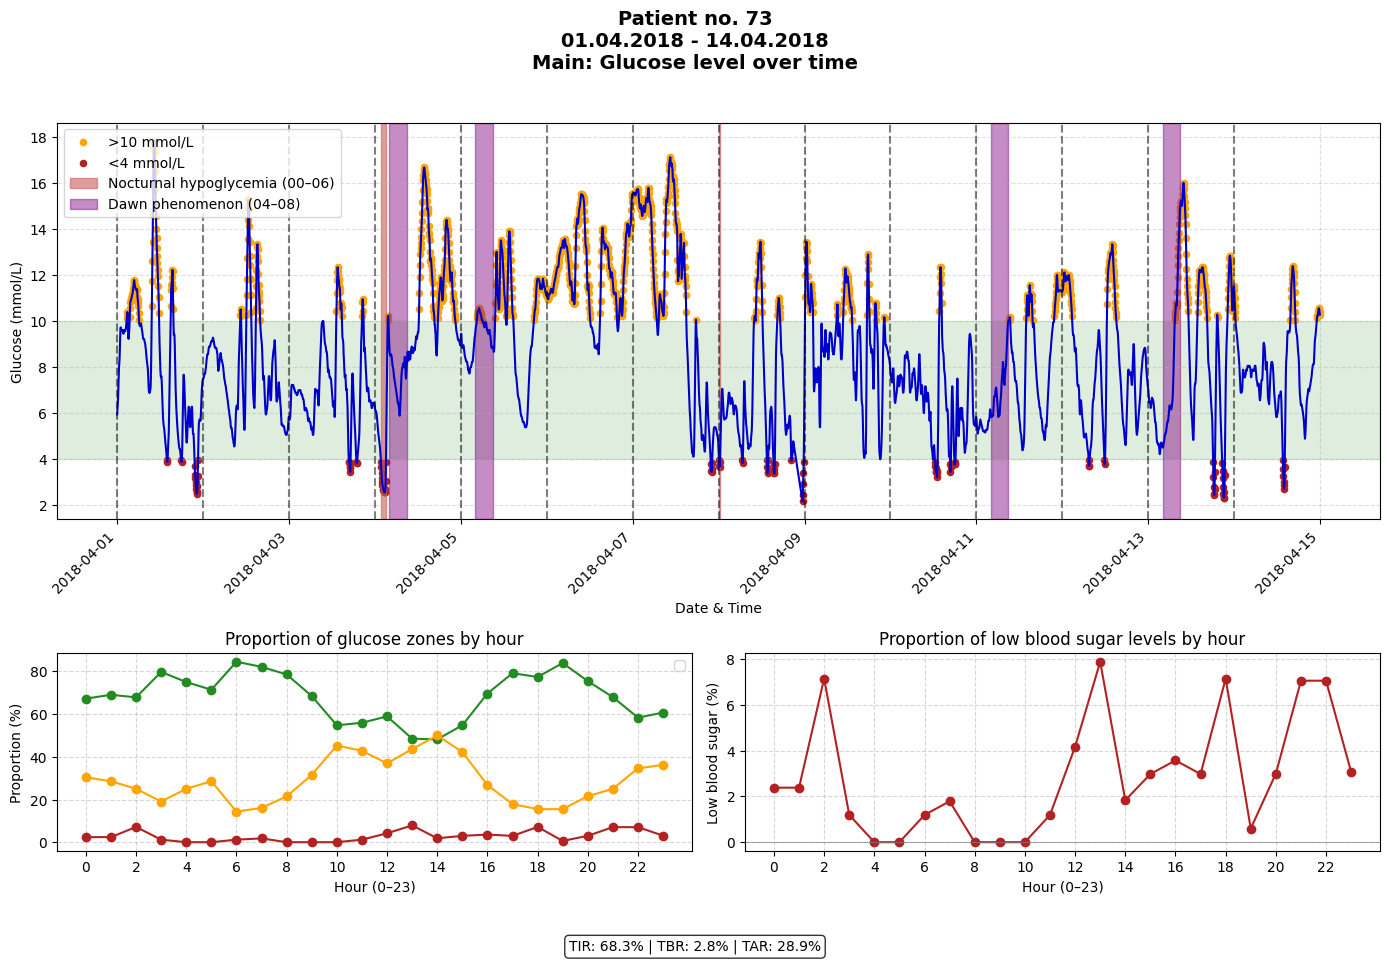

In [21]:
 r = predict_episode_summary(73, '2018-04-01', '2018-04-14')
 print_patient_report(r)

plot_patient_overview(
  pt=73,
  start_date='2018-04-01',
  end_date='2018-04-14',
  dclp3=dclp3
)


In [ ]:
 r = predict_episode_summary(167, '2018-05-17', '2018-05-31')
 print_patient_report(r)

plot_patient_overview(
  pt=167,
  start_date='2018-05-17',
  end_date='2018-05-31',
  dclp3=dclp3
)
